<a href="https://colab.research.google.com/github/A-Vineela/IIIT-H-Summer-School-2026/blob/main/tiny_char_transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tiny Character Transformer CVIT Summer School


## What we're building

A small **decoder-only Transformer** — the same architecture family as GPT — trained completely **from scratch** to do **character-level language modeling**. There is no pretrained model and no external API: every weight starts random, and the model learns purely from the training loop in this notebook.

**The task:** given the characters seen so far, predict the next character. Repeating this one step at a time is what lets the model generate new text.

## The data

We train on **Tiny Shakespeare** (~1.1M characters from Shakespeare's plays). It's small enough to train in minutes on a free Colab GPU, but structured enough (dialogue, speaker names, verse) that you can visually judge whether the model is actually learning something meaningful.

## The model

A ~0.8M-parameter decoder-only Transformer with causal self-attention. Small enough to train live in a workshop, but large enough to visibly progress through recognizable stages: random characters → word-like fragments → speaker names and Shakespeare-style dialogue.

## How to use this notebook

Pick one mode before running:

- `MODE = "train"`: train the model from scratch (a few minutes on a T4 GPU), and produce the loss/BPC plots yourself.
- `MODE = "load"`: skip training and load an already-trained model to explore its outputs immediately.

Runtime → Change runtime type → GPU (T4) if you use `MODE = "train"`.


## 1. Setup

Import the required libraries, set random seeds, and choose GPU/CPU. Nothing is trained or loaded here.


In [ ]:
import os
import csv
import math
import time
import zipfile
import urllib.request
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Reproducibility for the workshop demo.
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)
if device == "cpu":
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> GPU (T4) if training live.")


Using device: cuda


## 2. Building blocks

Before we run anything, we define every piece the model needs: how text becomes numbers (tokenization), the Transformer architecture itself, the training loop, and utilities for saving/loading a model.


### 2.1 Character-level tokenization helpers

Converting text into token ids for the model to process.


In [ ]:
def download_tiny_shakespeare(path="input.txt"):
    """Download Tiny Shakespeare and return the raw text."""
    url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
    urllib.request.urlretrieve(url, path)
    with open(path, "r", encoding="utf-8") as f:
        text = f.read()
    return text


def build_char_tokenizer(text):
    """Build character vocabulary and encode/decode helpers."""
    itos = sorted(list(set(text)))
    stoi = {ch: i for i, ch in enumerate(itos)}

    def encode(s):
        return [stoi[ch] for ch in s]

    def decode(ids):
        return "".join(itos[int(i)] for i in ids)

    data = torch.tensor(encode(text), dtype=torch.long)
    return itos, stoi, encode, decode, data


def build_loaded_char_tokenizer(itos, stoi):
    """Tokenizer for a loaded character model. Unknown prompt characters are skipped."""
    def encode(s):
        return [stoi[ch] for ch in s if ch in stoi]

    def decode(ids):
        return "".join(itos[int(i)] for i in ids)

    return encode, decode


### 2.2 Train/validation split and batching

We train on the first 90% of the character stream and validate on the final 10%. Each batch contains random contiguous character windows; the target is the same sequence shifted one character to the right.


In [ ]:
def split_data(data, train_fraction=0.9):
    n = int(train_fraction * len(data))
    return data[:n], data[n:]


def make_batcher(train_data, val_data, seq_len, batch_size, device):
    def get_batch(split):
        d = train_data if split == "train" else val_data
        ix = torch.randint(0, len(d) - seq_len - 1, (batch_size,))
        x = torch.stack([d[i:i + seq_len] for i in ix])
        y = torch.stack([d[i + 1:i + seq_len + 1] for i in ix])
        return x.to(device), y.to(device)
    return get_batch


### 2.3 The model

A minimal decoder-only transformer: token + positional embeddings, pre-norm transformer blocks with causal self-attention, and tied input/output embeddings.

The self-attention is *causal*, meaning each position can only attend to itself and earlier positions, never later ones. This matters because the model is being trained to predict the next character — if it could see future characters, it would just copy the answer instead of learning to predict it.


In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.proj = nn.Linear(d_model, d_model)
        self.dropout = dropout

    def forward(self, x):
        B, T, C = x.shape
        qkv = self.qkv(x).view(B, T, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        out = F.scaled_dot_product_attention(
            q, k, v,
            is_causal=True, # will apply masking
            dropout_p=self.dropout if self.training else 0.0,
        )
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        return self.proj(out)


class Block(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, dropout)
        self.ln2 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model, n_layers, n_heads, d_ff, seq_len, dropout):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(seq_len, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.ln_f = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size, bias=False)
        self.head.weight = self.tok_emb.weight  # weight tying
        self.seq_len = seq_len
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        x = self.ln_f(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=0.8, top_k=40):
        was_training = self.training
        self.eval()

        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.seq_len:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = -float("inf")

            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)

        if was_training:
            self.train()
        return idx


def build_model(vocab_size, d_model, n_layers, n_heads, d_ff, seq_len, dropout, device):
    model = TinyTransformerLM(vocab_size, d_model, n_layers, n_heads, d_ff, seq_len, dropout).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {n_params:,} ({n_params / 1e6:.2f}M)")
    return model


### 2.4 Training and generation utilities

We track validation loss and validation **BPC**. BPC is cross-entropy converted into bits per character: `BPC = loss / log(2)`. Lower validation BPC means the model is getting better at predicting/compressing the text.


In [ ]:
def cpu_state_dict(module):
    """Copy a model state_dict to CPU so it is safe to save/download from Colab."""
    return {k: v.detach().cpu().clone() for k, v in module.state_dict().items()}


@torch.no_grad()
def estimate_loss(model, get_batch, device, iters=20):
    model.eval()
    out = {}

    for split in ["train", "val"]:
        losses = torch.zeros(iters)
        for i in range(iters):
            x, y = get_batch(split)
            _, loss = model(x, y)
            losses[i] = loss.item()

        mean_loss = losses.mean().item()
        out[split] = {
            "loss": mean_loss,
            "bpc": mean_loss / math.log(2),
        }

    model.train()
    return out


@torch.no_grad()
def generate_text(model, prompt, encode, decode, device, n_tokens=400, temperature=0.8, top_k=40):
    ids = encode(prompt)
    if len(ids) == 0:
        raise ValueError("Prompt has no characters that exist in the vocabulary.")
    ids = torch.tensor([ids], dtype=torch.long).to(device)
    out = model.generate(ids, n_tokens, temperature=temperature, top_k=top_k)
    return decode(out[0].tolist())


def train_character_model(
    model,
    get_batch,
    encode,
    decode,
    device,
    max_steps=10000,
    eval_interval=200,
    lr=3e-4,
    prompt="to be or not to be",
    save_eval_checkpoints=False,
    checkpoint_dir="char_eval_checkpoints",
    showcase_checkpoint_steps={1000, 3000, 6000, 10000},
):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

    history = {
        "step": [],
        "train_loss": [],
        "val_loss": [],
        "train_bpc": [],
        "val_bpc": [],
    }
    snapshots = {}

    best_val_bpc = float("inf")
    best_val_loss = float("inf")
    best_step = 0
    best_state = None
    final_state = None

    snapshots[0] = generate_text(model, prompt, encode, decode, device)
    print("--- Step 0 (untrained) sample ---")
    print(snapshots[0])
    print()

    if save_eval_checkpoints:
        os.makedirs(checkpoint_dir, exist_ok=True)

    t0 = time.time()
    for step in range(1, max_steps + 1):
        xb, yb = get_batch("train")
        _, loss = model(xb, yb)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        if step % eval_interval == 0 or step == max_steps:
            metrics = estimate_loss(model, get_batch, device)

            history["step"].append(step)
            history["train_loss"].append(metrics["train"]["loss"])
            history["val_loss"].append(metrics["val"]["loss"])
            history["train_bpc"].append(metrics["train"]["bpc"])
            history["val_bpc"].append(metrics["val"]["bpc"])

            is_best = metrics["val"]["bpc"] < best_val_bpc
            if is_best:
                best_val_bpc = metrics["val"]["bpc"]
                best_val_loss = metrics["val"]["loss"]
                best_step = step
                best_state = cpu_state_dict(model)

            elapsed = time.time() - t0
            best_marker = "  <-- best" if is_best else ""
            print(
                f"step {step:5d} | "
                f"train loss {metrics['train']['loss']:.3f} | "
                f"val loss {metrics['val']['loss']:.3f} | "
                f"val BPC {metrics['val']['bpc']:.3f} | "
                f"{elapsed:.0f}s elapsed" + best_marker
            )

            snapshots[step] = generate_text(model, prompt, encode, decode, device)

            if save_eval_checkpoints and step in showcase_checkpoint_steps:
                ckpt_path = os.path.join(checkpoint_dir, f"char_step_{step:05d}.pt")
                torch.save({
                    "checkpoint_type": "char_step_checkpoint",
                    "step": step,
                    "model_state_dict": cpu_state_dict(model),
                    "val_loss": metrics["val"]["loss"],
                    "val_bpc": metrics["val"]["bpc"],
                    "sample_prompt": prompt,
                    "sample_text": snapshots[step],
                }, ckpt_path)
                print(f"  saved checkpoint: {ckpt_path}")

    print(f"\nTotal training time: {time.time() - t0:.0f}s")

    final_state = cpu_state_dict(model)

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
        print(f"Restored best checkpoint from step {best_step} with val BPC {best_val_bpc:.3f}.")

    training_info = {
        "history": history,
        "snapshots": snapshots,
        "best_step": best_step,
        "best_val_loss": best_val_loss,
        "best_val_bpc": best_val_bpc,
        "best_state": best_state,
        "final_state": final_state,
        "sample_prompt": prompt,
    }
    return model, training_info


### 2.5 Save/load utilities

The saved `.zip` pack is the fast classroom path. It contains the best model checkpoint, the training history CSV, and readable generation snapshots.


In [ ]:
def save_showcase_pack(
    model,
    training_info,
    itos,
    stoi,
    vocab_size,
    seq_len,
    n_layers,
    n_heads,
    d_model,
    d_ff,
    dropout,
    save_path="tinylm.pt",
    history_csv_path="char_training_history.csv",
    snapshot_txt_path="char_generation_snapshots.txt",
    live_pack_path="tinylm_metadata.zip",
):
    history = training_info["history"]
    snapshots = training_info["snapshots"]
    prompt = training_info["sample_prompt"]

    checkpoint = {
        "checkpoint_type": "char_best_checkpoint",
        "model_state_dict": cpu_state_dict(model),
        "final_model_state_dict": training_info["final_state"],
        "itos": itos,
        "stoi": stoi,
        "VOCAB_SIZE": vocab_size,
        "SEQ_LEN": seq_len,
        "N_LAYERS": n_layers,
        "N_HEADS": n_heads,
        "D_MODEL": d_model,
        "D_FF": d_ff,
        "DROPOUT": dropout,
        "best_step": training_info["best_step"],
        "best_val_loss": training_info["best_val_loss"],
        "best_val_bpc": training_info["best_val_bpc"],
        "history": history,
        "snapshots": snapshots,
        "sample_prompt": prompt,
    }

    torch.save(checkpoint, save_path)
    print(f"Saved best model to {save_path}")
    print(
        f"Best step: {training_info['best_step']} | "
        f"best val loss: {training_info['best_val_loss']:.3f} | "
        f"best val BPC: {training_info['best_val_bpc']:.3f}"
    )

    with open(history_csv_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["step", "train_loss", "val_loss", "train_bpc", "val_bpc"])
        writer.writeheader()
        for i in range(len(history["step"])):
            writer.writerow({
                "step": history["step"][i],
                "train_loss": history["train_loss"][i],
                "val_loss": history["val_loss"][i],
                "train_bpc": history["train_bpc"][i],
                "val_bpc": history["val_bpc"][i],
            })

    with open(snapshot_txt_path, "w", encoding="utf-8") as f:
        f.write(f"Sample prompt: {prompt}\n")
        f.write(f"Best checkpoint: step {training_info['best_step']}, val BPC {training_info['best_val_bpc']:.3f}\n")
        f.write("=" * 80 + "\n\n")
        for step in sorted(snapshots.keys()):
            f.write(f"=== step {step} ===\n")
            f.write(snapshots[step])
            f.write("\n\n")

    with zipfile.ZipFile(live_pack_path, "w", zipfile.ZIP_DEFLATED) as z:
        z.write(save_path)
        z.write(history_csv_path)
        z.write(snapshot_txt_path)

    print(f"Saved live showcase pack to {live_pack_path}")

    try:
        from google.colab import files
        files.download(save_path)
        files.download(live_pack_path)
    except Exception:
        print("Not running in Colab. Download the .pt and .zip files from the notebook file browser.")

    return checkpoint


def maybe_upload_zip(zip_path, upload_zip):
    if upload_zip:
        try:
            from google.colab import files
            uploaded = files.upload()
            if uploaded:
                zip_path = list(uploaded.keys())[0]
        except Exception:
            print("Upload is only available in Colab. Using ZIP_PATH instead.")
    return zip_path


def load_showcase_pack(zip_path, unpack_dir, device, upload_zip=False):
    zip_path = maybe_upload_zip(zip_path, upload_zip)
    print("Using zip:", zip_path)

    os.makedirs(unpack_dir, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(unpack_dir)

    print("Unpacked files:")
    for fname in os.listdir(unpack_dir):
        print(" -", fname)

    model_path = os.path.join(unpack_dir, "tiny_char_transformer_shakespeare_best.pt")
    snapshot_path = os.path.join(unpack_dir, "char_generation_snapshots.txt")
    history_path = os.path.join(unpack_dir, "char_training_history.csv")

    checkpoint = torch.load(model_path, map_location=device)

    itos = checkpoint["itos"]
    stoi = checkpoint["stoi"]
    encode, decode = build_loaded_char_tokenizer(itos, stoi)

    model = build_model(
        checkpoint["VOCAB_SIZE"],
        checkpoint["D_MODEL"],
        checkpoint["N_LAYERS"],
        checkpoint["N_HEADS"],
        checkpoint["D_FF"],
        checkpoint["SEQ_LEN"],
        checkpoint["DROPOUT"],
        device,
    )
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    history = checkpoint.get("history")
    if history is None and os.path.exists(history_path):
        history = {"step": [], "train_loss": [], "val_loss": [], "train_bpc": [], "val_bpc": []}
        with open(history_path, "r", encoding="utf-8") as f:
            reader = csv.DictReader(f)
            for row in reader:
                history["step"].append(int(row["step"]))
                history["train_loss"].append(float(row["train_loss"]))
                history["val_loss"].append(float(row["val_loss"]))
                history["train_bpc"].append(float(row["train_bpc"]))
                history["val_bpc"].append(float(row["val_bpc"]))

    snapshots = checkpoint.get("snapshots")
    snapshot_text = None
    if os.path.exists(snapshot_path):
        with open(snapshot_path, "r", encoding="utf-8") as f:
            snapshot_text = f.read()

    print("Loaded character model successfully.")
    print(f"Best step: {checkpoint.get('best_step', 'unknown')}")
    if "best_val_bpc" in checkpoint:
        print(f"Best validation BPC: {checkpoint['best_val_bpc']:.3f}")

    return {
        "model": model,
        "history": history,
        "snapshots": snapshots,
        "snapshot_text": snapshot_text,
        "checkpoint": checkpoint,
        "itos": itos,
        "stoi": stoi,
        "encode": encode,
        "decode": decode,
    }


### 2.6 Visualizing training and generations

Two helper functions used later: one plots the loss/BPC curves, and one displays generated text side-by-side across training steps so you can see the model's outputs evolve.


In [ ]:
def plot_training_history(history):
    if history is None or len(history.get("step", [])) == 0:
        print("No training history available to plot.")
        return

    plt.figure(figsize=(8, 5))
    plt.plot(history["step"], history["train_loss"], label="train loss")
    plt.plot(history["step"], history["val_loss"], label="val loss")
    plt.xlabel("step")
    plt.ylabel("cross-entropy loss")
    plt.title("Training progress: loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history["step"], history["train_bpc"], label="train BPC")
    plt.plot(history["step"], history["val_bpc"], label="val BPC")
    plt.xlabel("step")
    plt.ylabel("bits per character")
    plt.title("Training progress: BPC")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def show_generation_progression(snapshots=None, snapshot_text=None):
    if snapshots:
        for step in sorted(snapshots.keys()):
            print(f"=== step {step} ===")
            print(snapshots[step])
            print()
    elif snapshot_text:
        print(snapshot_text)
    else:
        print("No generation snapshots available.")


## 3. Choose train or load

Set `MODE` below:

- `"load"` — see results immediately using an already-trained model (recommended for a live class demo).
- `"train"` — train a fresh model from scratch and watch the process happen.


In [ ]:
# to load a pretrained model
MODE = "load" #train

# to train a new model
# MODE = "train"

# Load mode settings.
ZIP_PATH = "tiny_char_transformer_live_showcase_pack.zip"
UPLOAD_ZIP = True  # in Colab, set True to upload the zip from your computer
UNPACK_DIR = "live_showcase_pack"

# Train mode settings.
SEQ_LEN = 128
BATCH_SIZE = 128
N_LAYERS = 4
N_HEADS = 4
D_MODEL = 128
D_FF = 4 * D_MODEL
DROPOUT = 0.5
MAX_STEPS = 10000
EVAL_INTERVAL = 200
LR = 3e-4
SAMPLE_PROMPT = "to be or not to be"

# Optional: turn this on if you want actual model files at selected steps.
# For most workshops, saved text snapshots are enough and much lighter.
SAVE_EVAL_CHECKPOINTS = False
CHECKPOINT_DIR = "char_eval_checkpoints"
SHOWCASE_CHECKPOINT_STEPS = {1000, 3000, 6000, 10000}

if MODE not in {"train", "load"}:
    raise ValueError("MODE must be either 'train' or 'load'.")

print("Selected MODE:", MODE)


Selected MODE: load


## 4A. Train path

Runs only if `MODE = "train"`. Downloads Tiny Shakespeare, builds the character vocabulary, trains the Transformer, and saves a checkpoint plus a shareable results package at the end.


In [ ]:
if MODE == "train":
    text = download_tiny_shakespeare("input.txt")
    print(f"Total characters: {len(text):,}")
    print(f"Sample:\n{text[:300]}")

    itos, stoi, encode, decode, data = build_char_tokenizer(text)
    VOCAB_SIZE = len(itos)
    print(f"Vocab size: {VOCAB_SIZE}")
    print(f"Encoded data length: {len(data):,} characters")
    print("Characters in vocab:")
    print("".join(itos))

    train_data, val_data = split_data(data)
    print(f"Train tokens: {len(train_data):,}  Val tokens: {len(val_data):,}")

    get_batch = make_batcher(train_data, val_data, SEQ_LEN, BATCH_SIZE, device)
    xb, yb = get_batch("train")
    print("batch shape:", xb.shape)

    model = build_model(VOCAB_SIZE, D_MODEL, N_LAYERS, N_HEADS, D_FF, SEQ_LEN, DROPOUT, device)

    model, training_info = train_character_model(
        model=model,
        get_batch=get_batch,
        encode=encode,
        decode=decode,
        device=device,
        max_steps=MAX_STEPS,
        eval_interval=EVAL_INTERVAL,
        lr=LR,
        prompt=SAMPLE_PROMPT,
        save_eval_checkpoints=SAVE_EVAL_CHECKPOINTS,
        checkpoint_dir=CHECKPOINT_DIR,
        showcase_checkpoint_steps=SHOWCASE_CHECKPOINT_STEPS,
    )

    checkpoint = save_showcase_pack(
        model=model,
        training_info=training_info,
        itos=itos,
        stoi=stoi,
        vocab_size=VOCAB_SIZE,
        seq_len=SEQ_LEN,
        n_layers=N_LAYERS,
        n_heads=N_HEADS,
        d_model=D_MODEL,
        d_ff=D_FF,
        dropout=DROPOUT,
    )

    history = training_info["history"]
    snapshots = training_info["snapshots"]
    snapshot_text = None
else:
    print("MODE is 'load'; skipping training.")


MODE is 'load'; skipping training.


## 4B. Load path

Runs only if `MODE = "load"`. Loads an already-trained model together with its saved training history and sample generations, so you can jump straight to exploring results.


In [ ]:
# load zip file as shared tinylm_metadata.zip

if MODE == "load":
    loaded = load_showcase_pack(
        zip_path='tinylm_metadata.zip',
        unpack_dir=UNPACK_DIR,
        device=device,
        upload_zip=UPLOAD_ZIP,
    )

    model = loaded["model"]
    history = loaded["history"]
    snapshots = loaded["snapshots"]
    snapshot_text = loaded["snapshot_text"]
    checkpoint = loaded["checkpoint"]
    itos = loaded["itos"]
    stoi = loaded["stoi"]
    encode = loaded["encode"]
    decode = loaded["decode"]
else:
    print("MODE is 'train'; skipping zip loading.")


## 5. Loss and BPC curves

This is the main quantitative evidence that the model is learning: both loss and BPC (bits per character — a measure of how well the model compresses/predicts the text) should decrease over training.


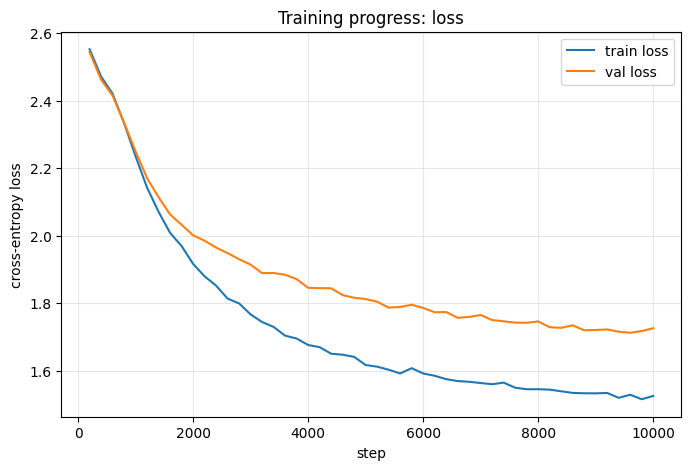

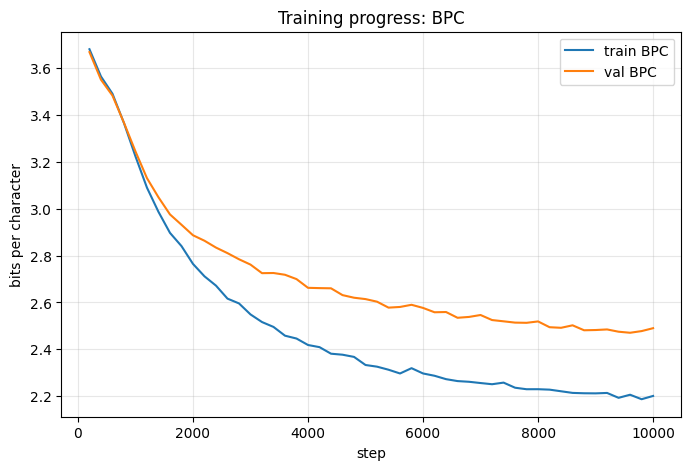

In [ ]:
plot_training_history(history)


## 6. Compare generations across training

The model starts with random characters. As training progresses, it should first learn local character patterns, then word-like fragments, then Shakespeare-like formatting with speaker names and dialogue.

Look at the step-0 output and the final-step output side by side: what's different? Try to spot the point where it stops looking like noise and starts looking like *language* — then the point where it starts looking like *Shakespeare* specifically.


In [ ]:
show_generation_progression(snapshots=snapshots, snapshot_text=snapshot_text)


=== step 0 ===
to be or not to bedF3u :e;Rn-bzDP'DnZ-P-t'EYomddXF3DnZ3UU,Pp:UEkn,PuHYIKKmUEP-NAS3FKL3pfwisSbcIwITP$DAsnGPpPsBpePupEGIcoEa;,QKe PvLRd$Pl&XGmFn,EEFi'wNpsI'&PpSa!mUapD&F
B,qZhaVFqpsXF:Pm:c,KnS-p .UVVupdFFwDw-is'wuVoEh?3assGDwqxxVwF3,,pRqZD-vmOZ?sPmd,FXjRp;'?lm;-DD?F-VKIaSS$wla$BRv:n!-KfmOPiW- hhKmuszL$kENVz-!$KUwXwu:saSSJoy G'?bE&UEB,Y'dDd p!-A3p;'KuVh;,LqBososo,S:.E!uRSI'DssZ!FtJ'?Rc;:i !NEwbFYKJBpPsmfrH'--os-'
.&v'

=== step 200 ===
to be or not to beathas the ghee w alous owand courelant the thell.
WDANRHind bese, hearerefangome an
FOROLE:
J:
FenYU:
AD:
CAnotouredowap w lhabare d GRDouas frethe hean,, mand hd fooketh s hy himethanga ar ced avereasple anothilarend he ne thithe te her tth coutou mann these fu thes nolllaminon hane that,
Whe wondis atre en ss thessour bu blond paste.
Thothiurr od, hamand s thatechess be mer; I cofe.
LE:


NICINo

=== step 400 ===
to be or not to be mecout wir oo of we
Anos wises d; whay onke be, f fole tol sorer
He:
And pus thy ve wine e b

## 7. Try your own prompt

The model used here is the best validation checkpoint. Change the prompt, temperature, and number of generated characters below. Lower temperature such as `0.6` or `0.7` usually gives safer text. Higher temperature gives more variety but more mistakes.

Temperature controls how "confident" the model is forced to be when picking the next character: low temperature sharpens the probability distribution toward the model's top guesses (safer, more repetitive), while high temperature flattens it so less-likely characters get picked more often (more variety, more mistakes).


In [ ]:
my_prompt = "the king said"  # change this
print(generate_text(model, my_prompt, encode, decode, device, n_tokens=400, temperature=0.75, top_k=40))


the king said,
Our so noble part of that do than of your contue
That make with lap with cale but think
The lust thou since ever than content in thy
brother saw the rest than out make not shall heart:
His wordship as the crown, what now the made one;
All proming to be lasst call, my head him she,
Marrrrcius well my king's lord, your speak
He man the gosssserves unships him death;
That what tell me that should I


## 8. What the checkpoint progression actually looks like

Here's a real example of how generated text changes over the course of training, taken from a full run of this notebook. Same prompt ("to be or not to be"), sampled at different steps:

![Checkpoint progression](attachment:checkpoint_progression.png)

A few things to notice as the steps go up:

- **Step 0** — pure noise. The model hasn't learned anything; output is random characters.
- **~800 steps** — the model has picked up basic character statistics: real letters, spaces, and line breaks start appearing, even though it's not forming real words yet.
- **~2000 steps** — word-like fragments show up. Not real English yet, but the *shapes* of words (plausible letter combinations, word lengths) are forming.
- **~4000–6000 steps** — dialogue formatting appears: line breaks, colons after names, a rhythm that looks like verse.
- **~6000–7000 steps** — actual Shakespeare character names start appearing (e.g. "CLARENCE", "PAULINA"), since the model has memorized which names occur in the training text and where they tend to go.
- **~9600 steps** — text reads as convincingly Shakespeare-*styled* (archaic phrasing, verse-like structure), even though sentence-level meaning is still weak. That's expected — this is a ~0.8M-parameter model trained on ~1.1M characters, not a large language model.

This is the same progression you should look for in your own run's output in section 6 above.


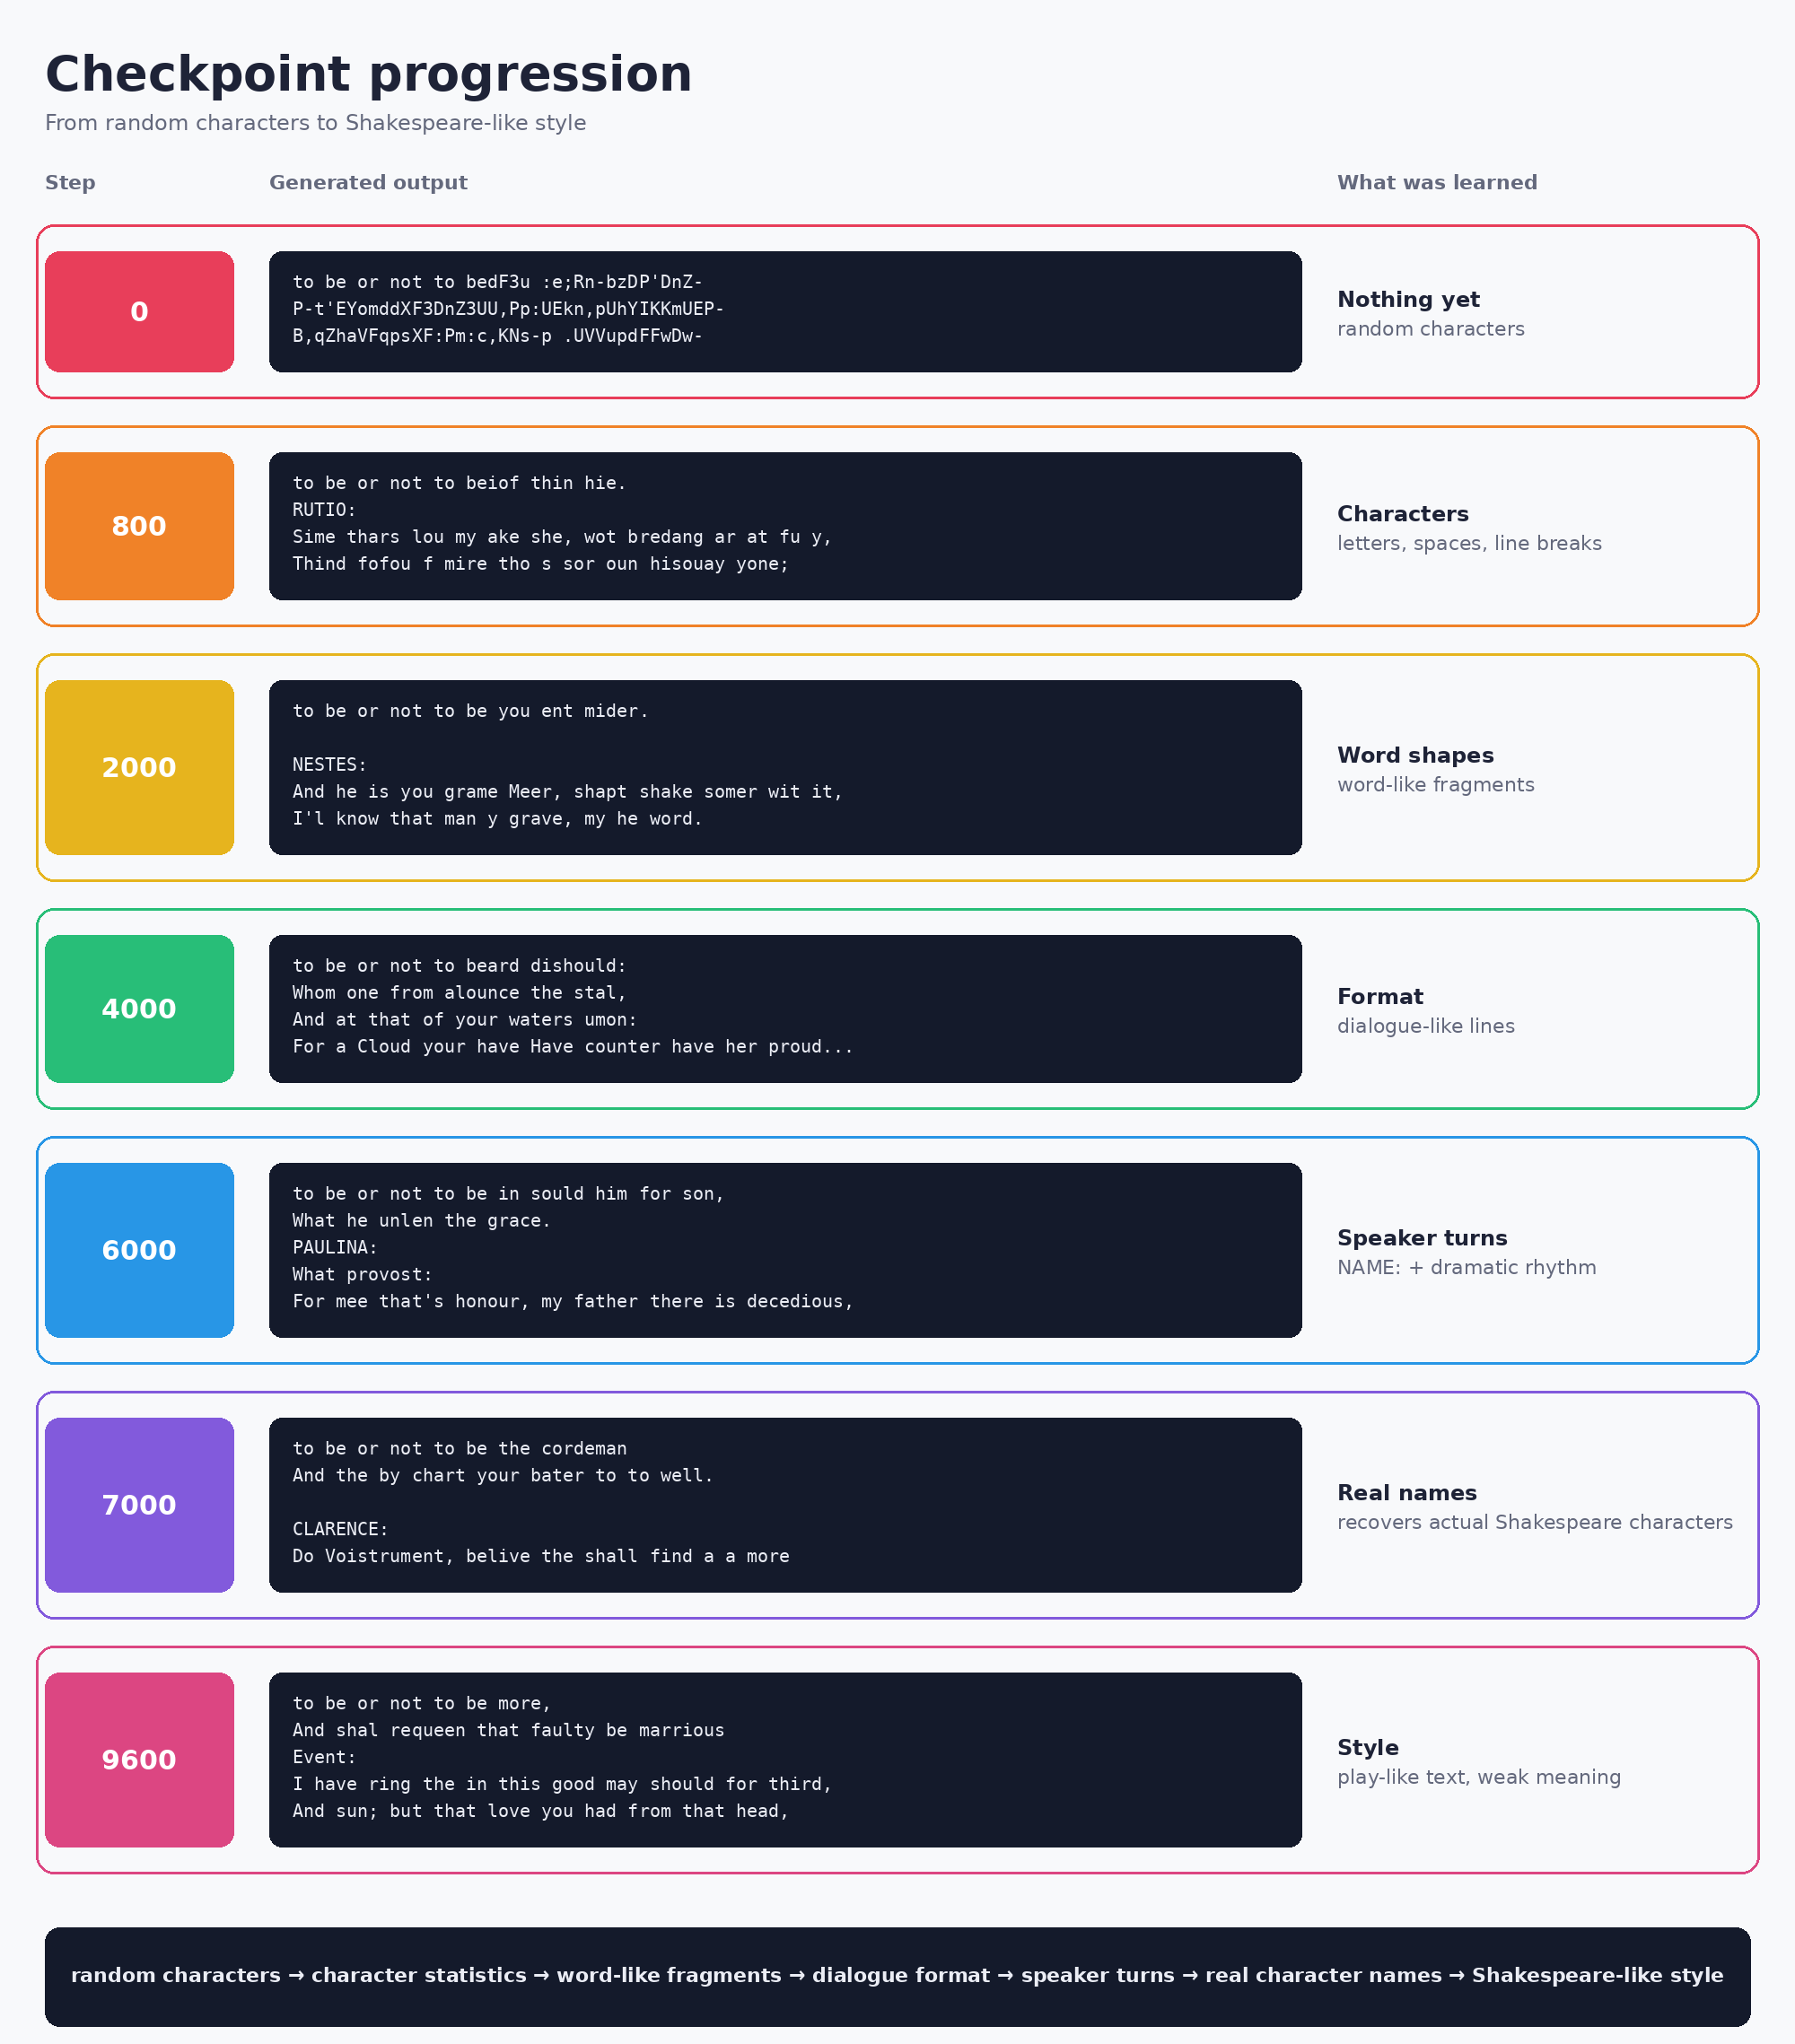

## 9. Try it yourself

If you want to go beyond just running the notebook, here are a few things worth experimenting with (set `MODE = "train"` to see the effect, since these all change what gets learned):

- **Change `DROPOUT`** (currently `0.5`) — try `0.1` or `0.0`. Does the model overfit faster? Does the generated text quality change?
- **Change `D_MODEL`, `N_LAYERS`, or `N_HEADS`** — make the model bigger or smaller. How does that affect training speed and the quality of generated text for the same number of steps?
- **Change `SEQ_LEN`** — shorter or longer context windows. Does the model still learn dialogue formatting (which depends on longer-range structure) if the context window is too short?
- **Swap in a different `.txt` file** in place of Tiny Shakespeare (any public-domain text works) — does the model pick up the *style* of the new text the same way?
- **Change the sampling `temperature` or `top_k`** in section 7 — find the point where the output stops being coherent.

For each change, the loss/BPC curves in section 5 are your first signal of whether something helped or hurt.
